<a href="https://colab.research.google.com/github/harshini-sudharsan/Iceland-2008/blob/main/iceland_inflation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

#use the iceland dataset final excel.

Research Question:
How did the 2008 financial crisis shock - through exchange rate collapse and oil price changes - transmit into CPI inflation in Iceland, and how did the Central Bank respond?

In [2]:
df = pd.read_excel("iceland_dataset_final.xlsx", index_col = "Date")
df['cbi_int'] = df['cbi_int'] * 100
df


,oil,cbi_int,isk_eur,cpi
Date,,,,
01-02-2000,27.775714,9.497143,71.99,5.6
01-03-2000,27.486087,9.600000,71.07,5.9
01-04-2000,22.764444,9.600000,70.06,6.0
01-05-2000,27.737619,9.600000,69.37,5.9
01-06-2000,29.795455,9.853000,72.34,5.5
...,...,...,...,...
01-10-2025,64.543478,7.500000,142.23,4.3
01-11-2025,63.797000,7.400000,146.83,3.7
01-12-2025,62.544286,7.250000,148.24,4.5


In [3]:
df1 = df.loc['01-02-2000':'01-12-2020']
print(f"  Observations remaining: {len(df1)}")

  Observations remaining: 251


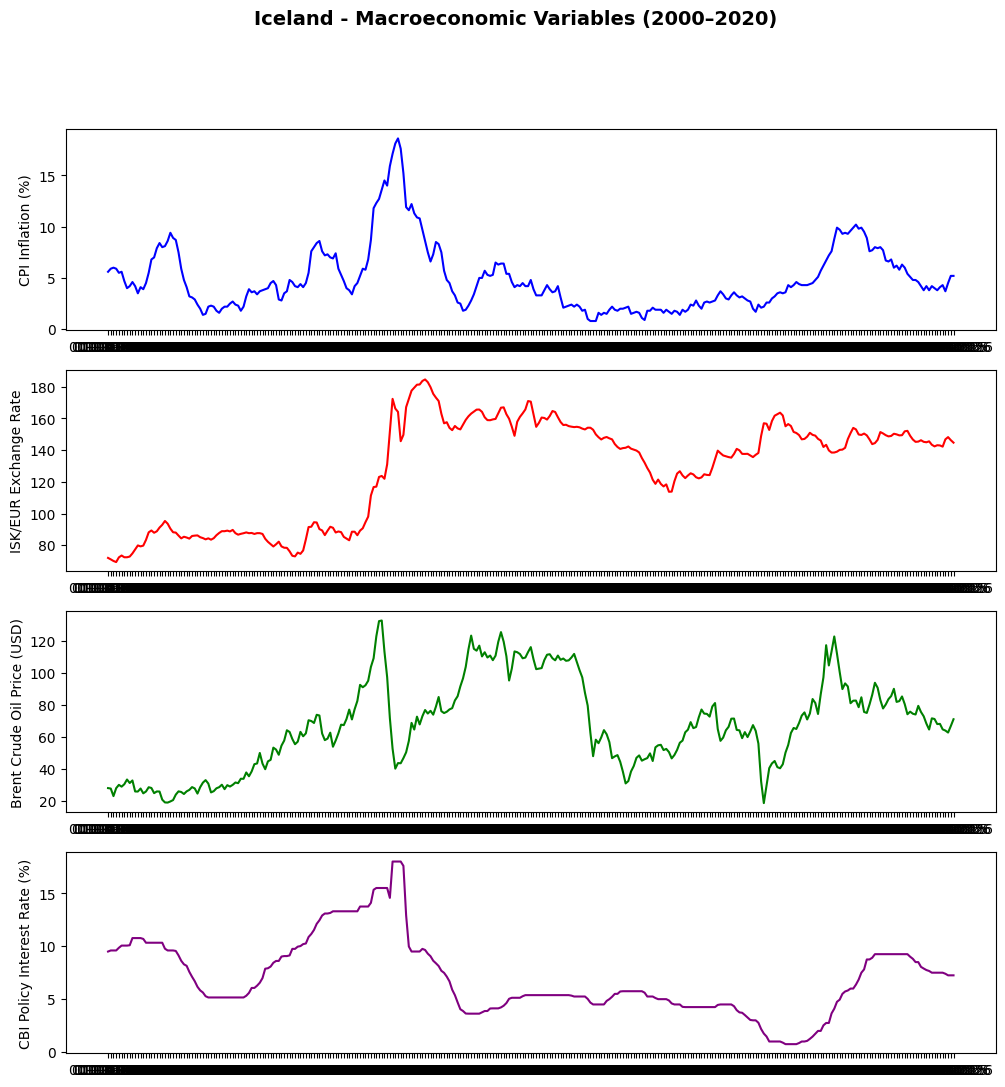

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle('Iceland - Macroeconomic Variables (2000–2020)',fontsize=14, fontweight='bold')
plots = [
    ('cpi',     'CPI Inflation (%)',            'blue'),
    ('isk_eur', 'ISK/EUR Exchange Rate',         'red'),
    ('oil',     'Brent Crude Oil Price (USD)',   'green'),
    ('cbi_int', 'CBI Policy Interest Rate (%)', 'purple'),
]

for ax, (col, label, color) in zip(axes, plots):
    ax.plot(df.index, df[col], color=color, linewidth=1.5)
    ax.set_ylabel(label, fontsize=10)


In [5]:
#first log transforming oil and isk_eur due to them being prices.
df['log_oil']     = np.log(df['oil'])
df['log_isk_eur'] = np.log(df['isk_eur'])

In [6]:
#adf
cols_to_test = ['log_oil', 'log_isk_eur', 'cpi', 'cbi_int']
for col in cols_to_test:
    stat, p_value, _, _, _, _ = adfuller(df[col], autolag='AIC')
    result = 'Stationary' if p_value < 0.05 else 'Non-stationary'
    print(f"{col:<20}  ADF stat={stat:.3f}  p={p_value:.4f}  {result}")

log_oil               ADF stat=-2.669  p=0.0795  Non-stationary
log_isk_eur           ADF stat=-2.052  p=0.2642  Non-stationary
cpi                   ADF stat=-2.526  p=0.1092  Non-stationary
cbi_int               ADF stat=-2.350  p=0.1562  Non-stationary


In [7]:
df['d_cpi']         = df['cpi'].diff()
df['d_log_oil']     = df['log_oil'].diff()       # monthly % change in oil price
df['d_log_isk_eur'] = df['log_isk_eur'].diff()
df['d_cbi_int']     = df['cbi_int'].diff()
df = df.replace([np.inf, -np.inf], np.nan)  # replace inf with NaN
df = df.dropna()                             # drop all NaN rows

cols_d = ['d_log_oil', 'd_log_isk_eur', 'd_cpi', 'd_cbi_int']
for col in cols_d:
    stat, p_value, _, _, _, _ = adfuller(df[col], autolag='AIC')
    result = 'Stationary' if p_value < 0.05 else 'Non-stationary'
    print(f"{col:<20}  ADF stat={stat:.3f}  p={p_value:.4f}  {result}")


d_log_oil             ADF stat=-12.556  p=0.0000  Stationary
d_log_isk_eur         ADF stat=-11.503  p=0.0000  Stationary
d_cpi                 ADF stat=-5.132  p=0.0000  Stationary
d_cbi_int             ADF stat=-4.588  p=0.0001  Stationary


time for correlation guys!

In [8]:
corr_vars = df[['d_cpi','d_log_isk_eur','d_log_oil','d_cbi_int']].copy()
corr_matrix = corr_vars.corr().round(3)
print(" Correlation Matrix:")
print(corr_matrix.to_string())

 Correlation Matrix:
               d_cpi  d_log_isk_eur  d_log_oil  d_cbi_int
d_cpi          1.000          0.180     -0.008      0.370
d_log_isk_eur  0.180          1.000     -0.154     -0.061
d_log_oil     -0.008         -0.154      1.000     -0.084
d_cbi_int      0.370         -0.061     -0.084      1.000


Including dummy for crisis:

In [27]:
df['crisis'] = 0
df['capital_controls'] = ((df.index >= '2008-11-01') & (df.index <= '2017-03-01')).astype(int)
df.index = pd.to_datetime(df.index, dayfirst=True)
crisis_mask = (df.index >= '2007-12-01') & (df.index <= '2009-06-01')
df.loc[crisis_mask, 'crisis'] = 1
df = df.dropna()
df['d_cbi_int_L1'] = df['d_cbi_int'].shift(4)

In [28]:
# Define X (independent variables) and Y (dependent variable)
df_crisis = df.loc['2007-06-01':'2010-12-01']

X = df_crisis[['d_log_isk_eur', 'd_log_oil', 'd_cbi_int_L1', 'crisis']]
y = df_crisis['d_cpi']

# Add constant (intercept β0) - always do this in OLS
X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit(cov_type='HC3')
print(ols_model.summary())
print(len(df['capital_controls']))

                            OLS Regression Results                            
Dep. Variable:                  d_cpi   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     1.902
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.130
Time:                        17:54:41   Log-Likelihood:                -63.405
No. Observations:                  43   AIC:                             136.8
Df Residuals:                      38   BIC:                             145.6
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.4112      0.210     -1.954

In [11]:
vars_data = df[['d_log_oil', 'd_log_isk_eur', 'd_cpi', 'd_cbi_int']]
model = VAR(vars_data)

# choose lag (you can test multiple)
results = model.fit(maxlags=4, ic='aic')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [12]:
irf = results.irf(12)

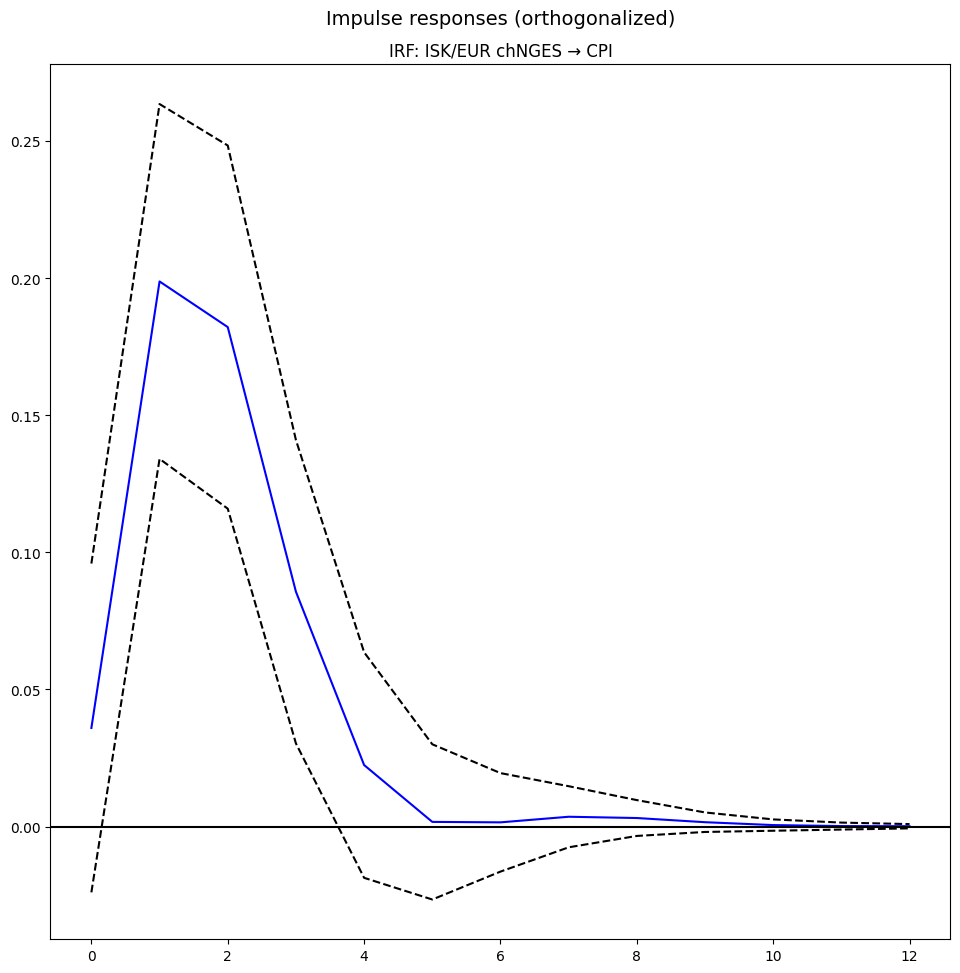

In [13]:
irf.plot(impulse='d_log_isk_eur', response='d_cpi',orth=True)
plt.title('IRF: ISK/EUR chNGES → CPI')
plt.show()

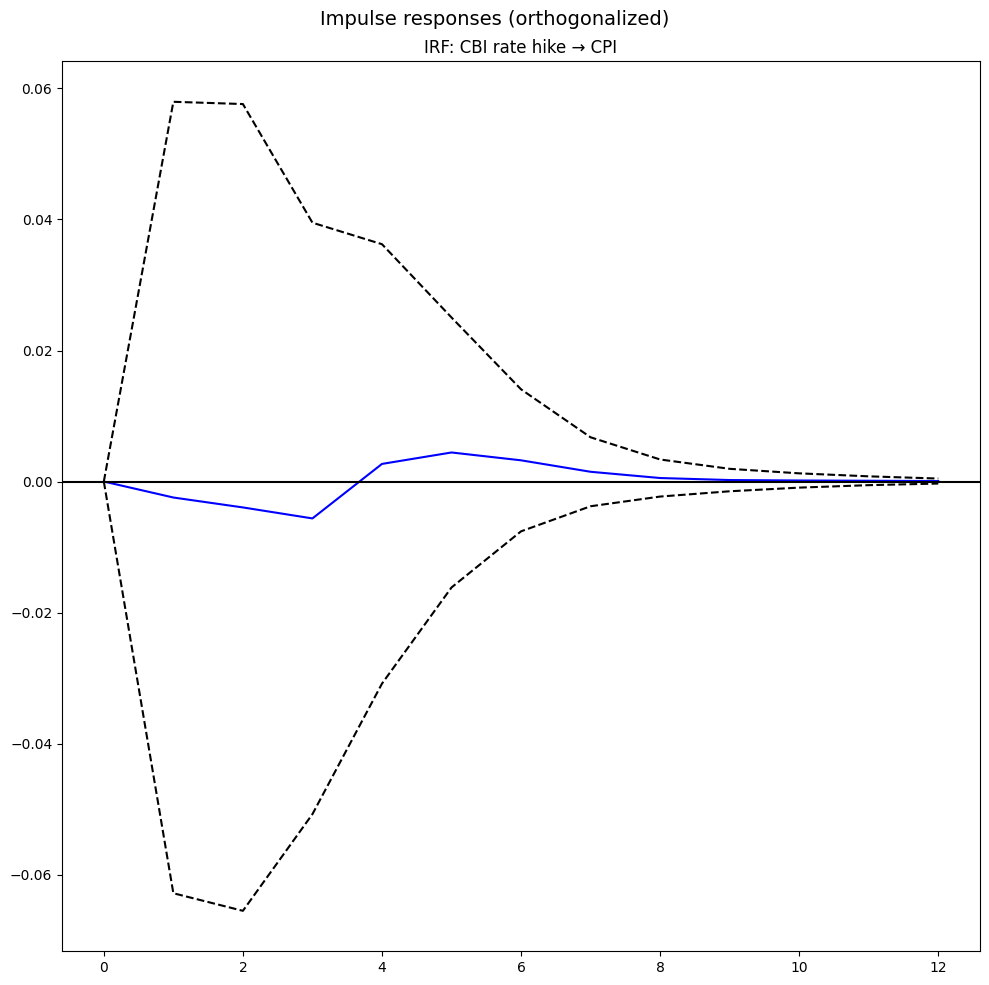

In [14]:
irf.plot(impulse='d_cbi_int', response='d_cpi', orth=True)
plt.title('IRF: CBI rate hike → CPI')
plt.tight_layout()
plt.show()

TESTING OLS


In [15]:
df['d_log_isk_eur_L1']=df['d_log_isk_eur'].shift(1)
df['d_cbi_int_L1'] = df['d_cbi_int'].shift(1)
df['iskL1xCC'] = df['d_log_isk_eur_L1'] * df['capital_controls']

In [16]:
df_ols = df[['d_cpi', 'd_log_isk_eur_L1','d_log_oil',
             'd_cbi_int', 'capital_controls']].dropna()
X = sm.add_constant(df_ols.drop('d_cpi', axis=1))
y = df_ols['d_cpi']


In [17]:
model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_cpi   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     9.721
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.80e-06
Time:                        17:53:30   Log-Likelihood:                -247.24
No. Observations:                 311   AIC:                             502.5
Df Residuals:                     307   BIC:                             517.4
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0209      0.031  

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


CHOW TEST

In [29]:
chow_df = ['d_cpi', 'd_log_isk_eur_L1', 'd_log_oil', 'd_cbi_int']

df_full = df[chow_df]
df_pre  = df[df.index < '2019-10-01'][chow_df][df['capital_controls'] == 0]
df_cc   = df[chow_df][df['capital_controls'] == 1]

/tmp/ipykernel_8327/270851770.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_pre  = df[df.index < '2019-10-01'][chow_df][df['capital_controls'] == 0]


In [30]:
print(f"Full sample: {len(df_full)} obs")
print(f"No-controls: {len(df_pre)} obs")
print(f"Controls period: {len(df_cc)} obs")

Full sample: 311 obs
No-controls: 133 obs
Controls period: 101 obs


In [31]:
def run_ols(data):
    X = sm.add_constant(data[['d_log_isk_eur_L1',
                               'd_log_oil',
                               'd_cbi_int']])
    y = data['d_cpi']
    return sm.OLS(y, X).fit()

res_full = run_ols(df_full)
res_pre  = run_ols(df_pre)
res_cc   = run_ols(df_cc)

print(f"RSS full:     {res_full.ssr:.4f}")
print(f"RSS pre:      {res_pre.ssr:.4f}")
print(f"RSS controls: {res_cc.ssr:.4f}")
print(f"RSS combined: {res_pre.ssr + res_cc.ssr:.4f}")

RSS full:     89.2920
RSS pre:      37.6016
RSS controls: 33.3689
RSS combined: 70.9705


In [32]:
from scipy import stats

k = 4        # number of parameters (constant + 3 variables)
n = len(df_full)   # 308
n1 = len(df_pre)   # 207
n2 = len(df_cc)    # 101

RSS_full     = res_full.ssr
RSS_combined = res_pre.ssr + res_cc.ssr

# Chow statistic
numerator   = (RSS_full - RSS_combined) / k
denominator = RSS_combined / (n - 2*k)

chow_stat = numerator / denominator
p_value   = 1 - stats.f.cdf(chow_stat, k, n - 2*k)

print(f"Chow statistic: {chow_stat:.4f}")
print(f"P-value:        {p_value:.4f}")
print(f"\nISK coeff pre-controls:  {res_pre.params['d_log_isk_eur_L1']:.4f}")
print(f"ISK coeff during controls: {res_cc.params['d_log_isk_eur_L1']:.4f}")

Chow statistic: 19.5554
P-value:        0.0000

ISK coeff pre-controls:  12.8016
ISK coeff during controls: 6.4337


In [33]:
from statsmodels.tsa.stattools import grangercausalitytests

print("Does ISK Granger-cause CPI?")
grangercausalitytests(df[['d_cpi', 'd_log_isk_eur']].dropna(), maxlag=4)

print("Does CPI Granger-cause CBI?")
grangercausalitytests(df[['d_cbi_int', 'd_cpi']].dropna(), maxlag=4)

Does ISK Granger-cause CPI?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=45.1195 , p=0.0000  , df_denom=307, df_num=1
ssr based chi2 test:   chi2=45.5604 , p=0.0000  , df=1
likelihood ratio test: chi2=42.5081 , p=0.0000  , df=1
parameter F test:         F=45.1195 , p=0.0000  , df_denom=307, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=22.8269 , p=0.0000  , df_denom=304, df_num=2
ssr based chi2 test:   chi2=46.4048 , p=0.0000  , df=2
likelihood ratio test: chi2=43.2341 , p=0.0000  , df=2
parameter F test:         F=22.8269 , p=0.0000  , df_denom=304, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=15.2455 , p=0.0000  , df_denom=301, df_num=3
ssr based chi2 test:   chi2=46.8002 , p=0.0000  , df=3
likelihood ratio test: chi2=43.5682 , p=0.0000  , df=3
parameter F test:         F=15.2455 , p=0.0000  , df_denom=301, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:   

{np.int64(1): ({'ssr_ftest': (np.float64(58.490731705076655),
    np.float64(2.6487491659123175e-13),
    np.float64(307.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(59.06230237320443),
    np.float64(1.527579050499983e-14),
    np.int64(1)),
   'lrtest': (np.float64(54.06188376301259),
    np.float64(1.9427357176986593e-13),
    np.int64(1)),
   'params_ftest': (np.float64(58.490731705076634),
    np.float64(2.6487491659123175e-13),
    np.float64(307.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(30.190878120481386),
    np.float64(1.0969270636701819e-12),
    np.float64(304.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(61.37487723176808),
    np.float64(4.7055971635357834e-14),
    np.int64(2)),
   'lrtest': (np.float64(55.98288883548639),
    np.float64(6.973810609137168e-13),
    np.int64(2)),
   'params_ftest': (np.float64(30.19087812048135),
    np.float64(1.096927063670204e-12),
    np.float64(304.0),
    2.0)},
   array([[0.,

In [34]:
print("Does CBI Granger-cause CPI?")
grangercausalitytests(df[['d_cpi', 'd_cbi_int']].dropna(), maxlag=4)

Does CBI Granger-cause CPI?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5717  , p=0.4502  , df_denom=307, df_num=1
ssr based chi2 test:   chi2=0.5773  , p=0.4474  , df=1
likelihood ratio test: chi2=0.5767  , p=0.4476  , df=1
parameter F test:         F=0.5717  , p=0.4502  , df_denom=307, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3046  , p=0.7377  , df_denom=304, df_num=2
ssr based chi2 test:   chi2=0.6192  , p=0.7338  , df=2
likelihood ratio test: chi2=0.6185  , p=0.7340  , df=2
parameter F test:         F=0.3046  , p=0.7377  , df_denom=304, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.6830  , p=0.5630  , df_denom=301, df_num=3
ssr based chi2 test:   chi2=2.0966  , p=0.5526  , df=3
likelihood ratio test: chi2=2.0895  , p=0.5540  , df=3
parameter F test:         F=0.6830  , p=0.5630  , df_denom=301, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:   

{np.int64(1): ({'ssr_ftest': (np.float64(0.5716982513194419),
    np.float64(0.4501646491732737),
    np.float64(307.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.5772848791824983),
    np.float64(0.447378533805761),
    np.int64(1)),
   'lrtest': (np.float64(0.5767480329275259),
    np.float64(0.4475898186668609),
    np.int64(1)),
   'params_ftest': (np.float64(0.5716982513194202),
    np.float64(0.4501646491732737),
    np.float64(307.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.3045670192175624),
    np.float64(0.7376673574797241),
    np.float64(304.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.619152690383071),
    np.float64(0.7337577503841188),
    np.int64(2)),
   'lrtest': (np.float64(0.6185332102286338),
    np.float64(0.7339850597679785),
    np.int64(2)),
   'params_ftest': (np.float64(0.30456701921758594),
    np.float64(0.7376673574797117),
    np.float64(304.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
       

Capital controls and its effect on exchange rate:

---



In [35]:
pre_cc   = df[df.index < '2008-11-01']['d_log_isk_eur']
during_cc = df[(df.index >= '2008-11-01') & (df.index < '2017-03-01')]['d_log_isk_eur']
post_cc  = df[df.index >= '2017-03-01']['d_log_isk_eur']

print(f"ISK volatility pre-controls:    {pre_cc.std():.4f}")
print(f"ISK volatility during controls: {during_cc.std():.4f}")
print(f"ISK volatility post-controls:   {post_cc.std():.4f}")

# Mean ISK change across periods
print(f"\nMean ISK change pre:    {pre_cc.mean():.4f}")
print(f"Mean ISK change during: {during_cc.mean():.4f}")
print(f"Mean ISK change post:   {post_cc.mean():.4f}")

ISK volatility pre-controls:    0.0319
ISK volatility during controls: 0.0280
ISK volatility post-controls:   0.0190

Mean ISK change pre:    0.0074
Mean ISK change during: -0.0025
Mean ISK change post:   0.0018


In [36]:
from scipy.stats import levene, bartlett

stat_l, p_l = levene(pre_cc, during_cc, post_cc)
stat_b, p_b = bartlett(pre_cc, during_cc, post_cc)

print(f"Levene test:   stat={stat_l:.4f}, p={p_l:.4f}")
print(f"Bartlett test: stat={stat_b:.4f}, p={p_b:.4f}")

# Also pairwise
from scipy.stats import levene as lev
s1, p1 = lev(pre_cc, during_cc)
s2, p2 = lev(during_cc, post_cc)
s3, p3 = lev(pre_cc, post_cc)

print(f"\nPre vs During:  p={p1:.4f}")
print(f"During vs Post: p={p2:.4f}")
print(f"Pre vs Post:    p={p3:.4f}")

Levene test:   stat=4.6811, p=0.0099
Bartlett test: stat=27.4241, p=0.0000

Pre vs During:  p=0.1747
During vs Post: p=0.1018
Pre vs Post:    p=0.0016


Philips curve for Iceland:

---



In [37]:
unemp_df = pd.read_csv('unemp_ice.csv')

In [38]:
unemp_df

,Date,unemp,cpi
0,01-01-2003,5.3,1.4
1,01-02-2003,4.2,1.5
2,01-03-2003,3.1,2.2
3,01-04-2003,2.9,2.3
4,01-05-2003,6.4,2.2
...,...,...,...
272,01-09-2025,3.2,4.1
273,01-10-2025,4.4,4.3
274,01-11-2025,6.5,3.7
275,01-12-2025,4.2,4.5


In [40]:
# Define periods
unemp_df.index = pd.to_datetime(unemp_df['Date'], dayfirst=True)

crisis   = unemp_df[(unemp_df.index >= '2008-01-01') &
                    (unemp_df.index <= '2011-12-01')]
post     = unemp_df[(unemp_df.index > '2011-12-01') & (unemp_df.index <= '2019-12-01')]
pre      = unemp_df[unemp_df.index < '2008-01-01']

# Run three separate Phillips curve regressions
def pc_ols(data):
    X = sm.add_constant(data['unemp'])
    y = data['cpi']
    return sm.OLS(y, X).fit(cov_type='HC3')

res_pre    = pc_ols(pre)
res_crisis = pc_ols(crisis)
res_post   = pc_ols(post)

print(f"Pre-crisis    — unemployment coef: {res_pre.params[1]:.4f}, p={res_pre.pvalues[1]:.4f}")
print(f"Crisis        — unemployment coef: {res_crisis.params[1]:.4f}, p={res_crisis.pvalues[1]:.4f}")
print(f"Post-crisis   — unemployment coef: {res_post.params[1]:.4f}, p={res_post.pvalues[1]:.4f}")

Pre-crisis    — unemployment coef: -0.2846, p=0.2916
Crisis        — unemployment coef: -0.5750, p=0.0103
Post-crisis   — unemployment coef: 0.3844, p=0.0000


/tmp/ipykernel_8327/2899516599.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Pre-crisis    — unemployment coef: {res_pre.params[1]:.4f}, p={res_pre.pvalues[1]:.4f}")
/tmp/ipykernel_8327/2899516599.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Pre-crisis    — unemployment coef: {res_pre.params[1]:.4f}, p={res_pre.pvalues[1]:.4f}")
/tmp/ipykernel_8327/2899516599.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.ilo

/tmp/ipykernel_8327/4198568189.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Crisis     — coef: {res_crisis.params[1]:.4f}, p={res_crisis.pvalues[1]:.4f}")
/tmp/ipykernel_8327/4198568189.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Crisis     — coef: {res_crisis.params[1]:.4f}, p={res_crisis.pvalues[1]:.4f}")
/tmp/ipykernel_8327/4198568189.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Post

Crisis     — coef: -0.5750, p=0.0103
Post-crisis — coef: 0.3844, p=0.0000


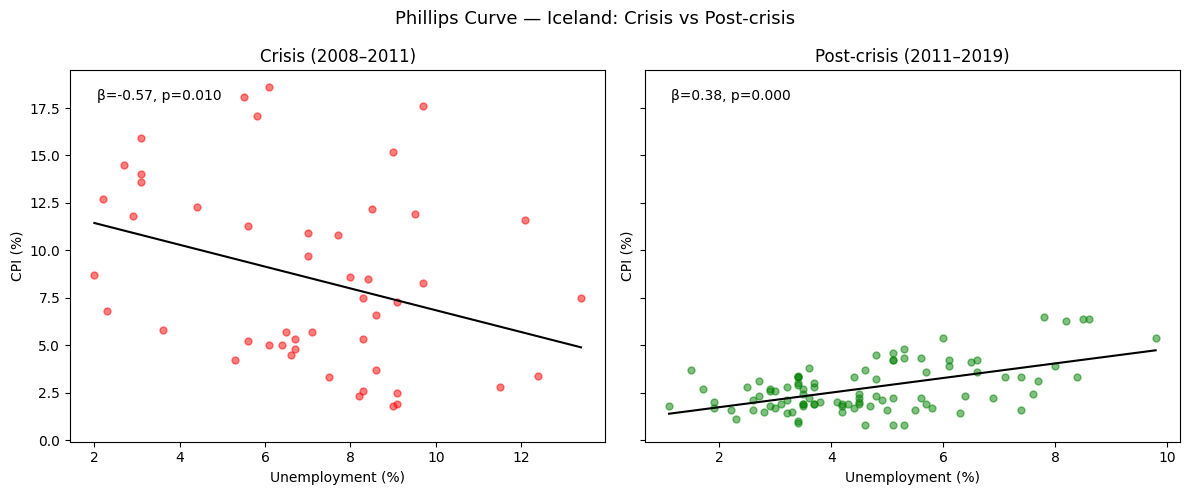

In [41]:
crisis    = unemp_df[(unemp_df.index >= '2008-01-01') &
                     (unemp_df.index <= '2011-12-01')]
post      = unemp_df[(unemp_df.index > '2011-12-01') &
                     (unemp_df.index <= '2019-12-01')]

res_crisis = pc_ols(crisis)
res_post   = pc_ols(post)

print(f"Crisis     — coef: {res_crisis.params[1]:.4f}, p={res_crisis.pvalues[1]:.4f}")
print(f"Post-crisis — coef: {res_post.params[1]:.4f}, p={res_post.pvalues[1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

periods = [
    (crisis, res_crisis, 'Crisis (2008–2011)',      'red'),
    (post,   res_post,   'Post-crisis (2011–2019)', 'green'),
]

for ax, (data, res, title, color) in zip(axes, periods):
    ax.scatter(data['unemp'], data['cpi'],
               alpha=0.5, color=color, s=25)
    x_range = np.linspace(data['unemp'].min(),
                           data['unemp'].max(), 100)
    y_fit = res.params[0] + res.params[1] * x_range
    ax.plot(x_range, y_fit, color='black', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Unemployment (%)')
    ax.set_ylabel('CPI (%)')
    coef = res.params[1]
    p    = res.pvalues[1]
    ax.annotate(f'β={coef:.2f}, p={p:.3f}',
                xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.suptitle('Phillips Curve — Iceland: Crisis vs Post-crisis', fontsize=13)
plt.tight_layout()
plt.show()

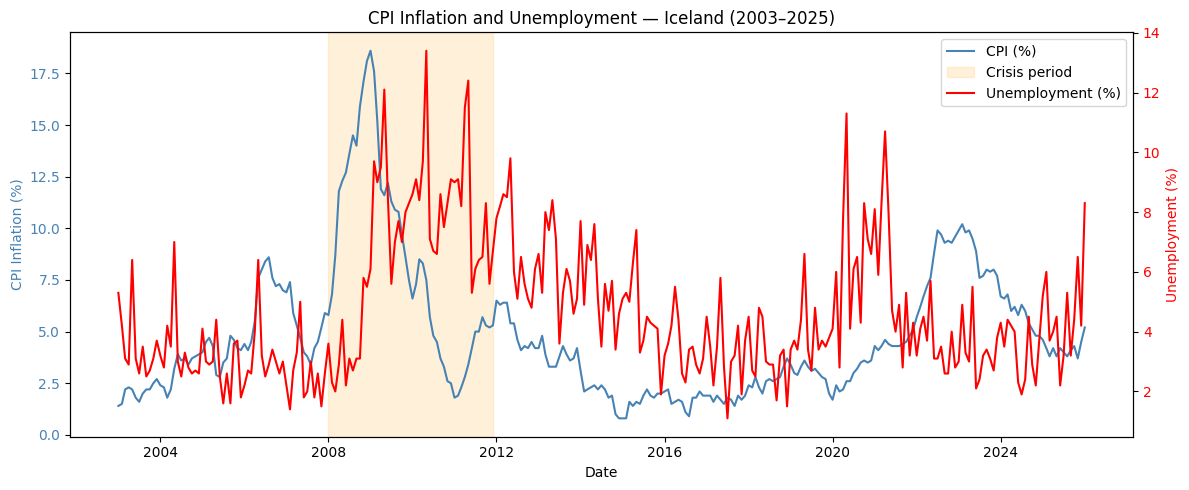

In [42]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.plot(unemp_df.index, unemp_df['cpi'],
         color='steelblue', linewidth=1.5, label='CPI (%)')
ax2.plot(unemp_df.index, unemp_df['unemp'],
         color='red', linewidth=1.5, label='Unemployment (%)')

# Shade crisis period
ax1.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2011-12-01'),
            alpha=0.15, color='orange', label='Crisis period')

ax1.set_ylabel('CPI Inflation (%)', color='steelblue')
ax2.set_ylabel('Unemployment (%)', color='red')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xlabel('Date')
ax1.set_title('CPI Inflation and Unemployment — Iceland (2003–2025)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()